<a href="https://colab.research.google.com/github/snig-17/QM-GRUNGE/blob/main/Regression/ols_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SuccessRate i = proportion of climbers who summited in expedition / year / route 𝑖

General Regression Equation:


SuccessRatei​=β0​+β1​Yeari​+β2​Seasoni​+β3​Citizenshipi​+β4​Routei​+β5​SupportRatioi​+β6​Crowdingi​+β7​Exped

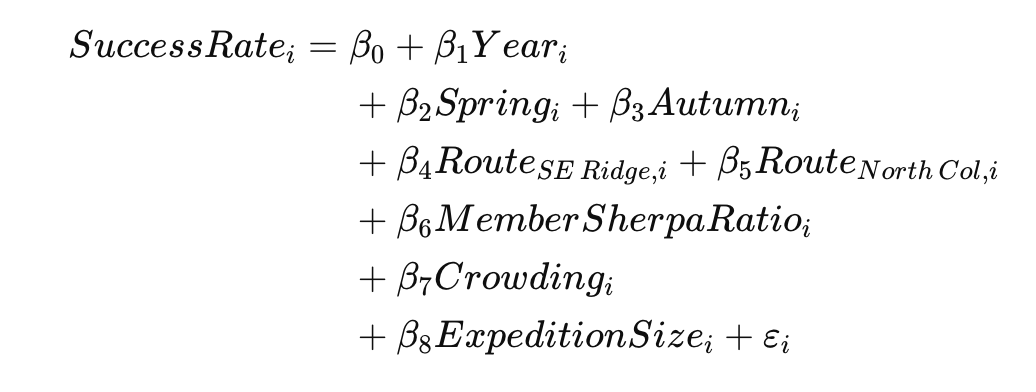

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%matplotlib inline

import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import pylab
import pandas as pd
import numpy as np

from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.iolib.summary2 import summary_col
import statsmodels.formula.api as smf

pylab.rcParams['figure.figsize'] = (10., 8.)
sns.set(font_scale=1.2)
sns.set_style("white")

Mounted at /content/drive


In [ ]:
df = pd.read_csv( "/content/drive/MyDrive/QM_Grunge_Data/expeditions5.csv")

In [ ]:
# --- 1) Keep only what we need (you can tweak this list) ---
keep = [
    "ExpedID",
    "Yr/Seas",
    "Year",
    "Nationalities",     # proxy for citizenship
    "route_codes",       # route category
    "mbr_hired_ratio",   # sherpa/member style support
    "group_size",        # expedition size proxy
    "total_members",     # another size proxy (often better than group_size)
    "success_rate"       # Y
]

df1 = df[keep].copy()

df1.head()


,ExpedID,Yr/Seas,Year,Nationalities,route_codes,mbr_hired_ratio,group_size,total_members,success_rate
0,EVER-901-03,1990 Spr,1990,"USA, China, USSR",2,0.00,39.0,39,0.512820513
1,EVER-901-04,1990 Spr,1990,Nepal,1,0.08,28.0,26,0.142857143
2,EVER-901-06,1990 Spr,1990,Australia,6,0.00,4.0,4,0.25
3,EVER-901-07,1990 Spr,1990,USA,1,0.30,13.0,10,0.692307692
4,EVER-901-08,1990 Spr,1990,"New Zealand, Belgium, Canada, Sweden, USA",1,0.10,11.0,10,0.636363636


In [ ]:
# Extract season from Yr/Seas
df1["Season"] = (
    df1["Yr/Seas"]
    .astype(str)
    .str.extract(r"(Spr|Sum|Aut|Fal|Win)", expand=False)
)

# Map abbreviations to full names (optional but nicer for write-up)
season_map = {
    "Spr": "Spring",
    "Sum": "Summer",
    "Aut": "Autumn",
    "Fal": "Autumn",
    "Win": "Winter"
}

df1["Season"] = df1["Season"].map(season_map)

df1[["Yr/Seas", "Year", "Season"]].head()

,Yr/Seas,Year,Season
0,1990 Spr,1990,Spring
1,1990 Spr,1990,Spring
2,1990 Spr,1990,Spring
3,1990 Spr,1990,Spring
4,1990 Spr,1990,Spring


In [ ]:
# Primary nationality = first listed nationality
df1["PrimaryNationality"] = (
    df1["Nationalities"]
    .astype(str)
    .str.split(",", n=1)
    .str[0]
    .str.strip()
)


In [ ]:
df1["MultiNational"] = (
    df1["Nationalities"]
    .astype(str)
    .str.contains(",")
    .astype(int)
)

df1[["Nationalities", "PrimaryNationality", "MultiNational"]].head()


,Nationalities,PrimaryNationality,MultiNational
0,"USA, China, USSR",USA,1
1,Nepal,Nepal,0
2,Australia,Australia,0
3,USA,USA,0
4,"New Zealand, Belgium, Canada, Sweden, USA",New Zealand,1


In [ ]:
df_clean = df1.drop(columns=["Nationalities", "Yr/Seas", "ExpedID"])
df_clean.head(20)


,Year,route_codes,mbr_hired_ratio,group_size,total_members,success_rate,Season,PrimaryNationality,MultiNational
0,1990,2,0.00,39.0,39,0.512820513,Spring,USA,1
1,1990,1,0.08,28.0,26,0.142857143,Spring,Nepal,0
2,1990,6,0.00,4.0,4,0.25,Spring,Australia,0
3,1990,1,0.30,13.0,10,0.692307692,Spring,USA,0
4,1990,1,0.10,11.0,10,0.636363636,Spring,New Zealand,1
5,1990,1,0.21,17.0,14,0.294117647,Autumn,S Korea,1
6,1990,1,0.09,24.0,22,0.333333333,Autumn,France,1
7,1990,6,0.18,13.0,11,0.538461538,Autumn,USA,1
8,1990,1,0.17,21.0,18,0.333333333,Autumn,France,1
9,1990,6,0.14,16.0,14,0.25,Autumn,Yugoslavia,1


In [ ]:
# Save cleaned dataset to CSV
df_clean.to_csv("everest_regression_dataset.csv", index=False)

1. Summary Statistics Table of Summary Statistics

2. Visualisation Exploratory Plots

3. Assumptions A. Independence B. Heteroscedasticity: Regression plots + Q-Q plot C. Multicollinearity: VIF + Correlation Matrix

4. Regression Regression Table For the moment, when you run the regression, ignore the fact that we have panel data and just run a regular regression of the form

𝑌=𝛽0+𝛽1𝑋+𝜖

In [ ]:
# 1. Summary Statistics (exclude dummy variables)
summary = (df_clean.drop(columns=["MultiNational"]).describe().round(2))

summary = summary.T
summary


,count,mean,std,min,25%,50%,75%,max
Year,2192.0,2009.21,8.73,1990.0,2003.0,2010.00,2016.0,2025.0
route_codes,2192.0,1.56,0.94,1.0,1.0,1.00,2.0,6.0
mbr_hired_ratio,2182.0,0.67,0.68,0.0,0.0,0.56,1.0,5.5
group_size,2190.0,10.59,10.87,1.0,3.0,7.00,14.0,79.0
total_members,2192.0,6.77,6.75,0.0,2.0,5.00,10.0,76.0


Dummy variables are excluded from the summary statistics table, as their means and standard deviations are not informative in the same way as continuous variables

In [ ]:
#Step 2: Visualisation

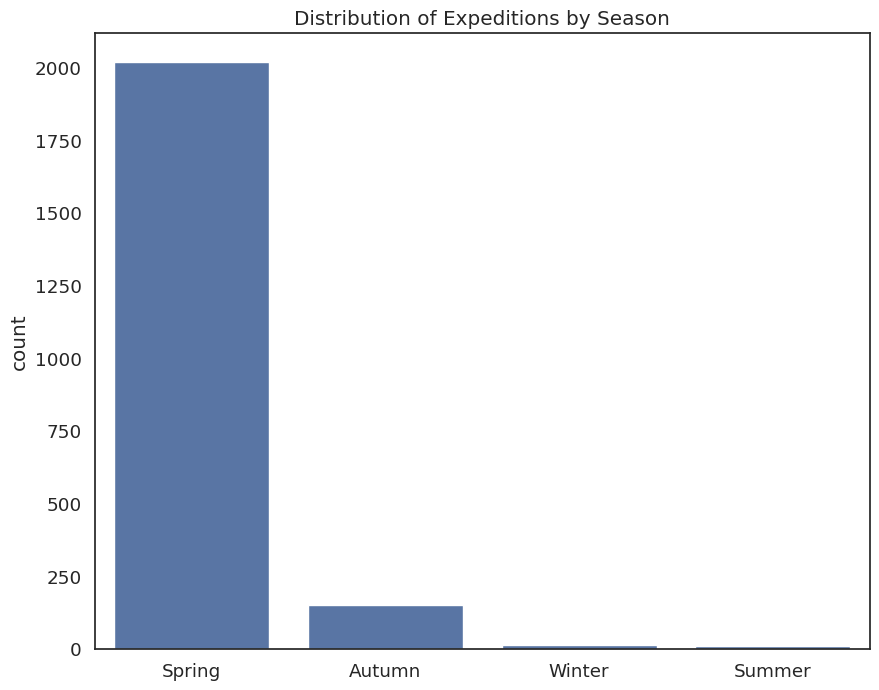

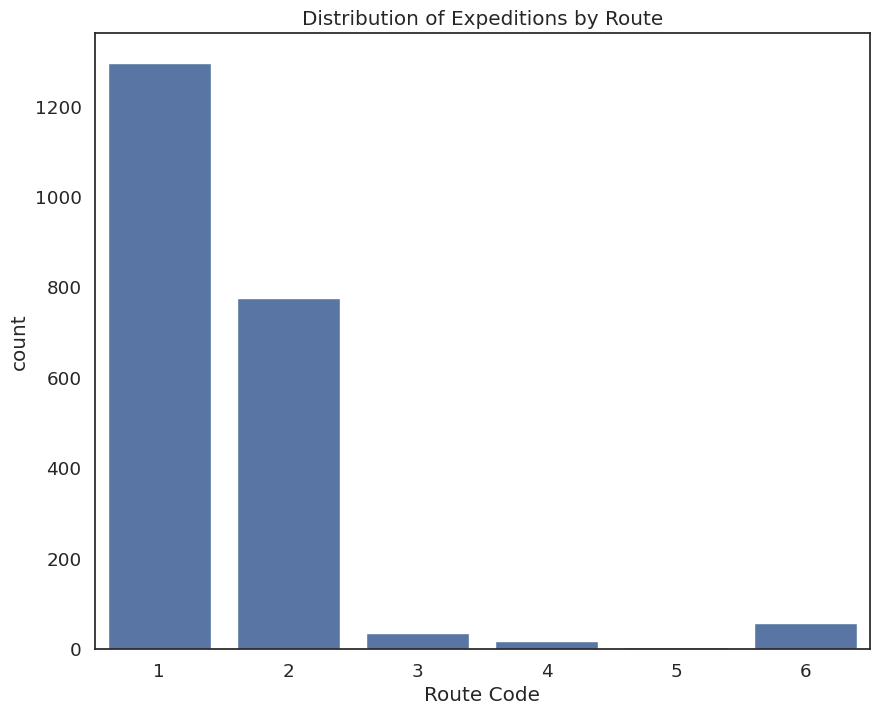

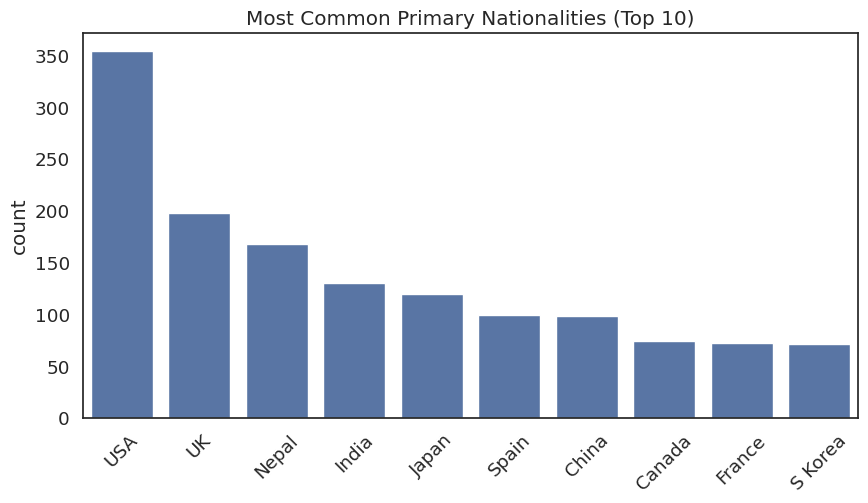

In [ ]:
#A. Distribution of categorical variables (count plots)
import seaborn as sns
import matplotlib.pyplot as plt

#Season distribution
sns.countplot(data=df_clean, x="Season")
plt.title("Distribution of Expeditions by Season")
plt.xlabel("")
plt.show()

#Route distribution
sns.countplot(data=df_clean, x="route_codes")
plt.title("Distribution of Expeditions by Route")
plt.xlabel("Route Code")
plt.show()

#Nationality distribution (only Top 10)
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_clean,
    x="PrimaryNationality",
    order=df_clean["PrimaryNationality"].value_counts().index[:10]
)
plt.title("Most Common Primary Nationalities (Top 10)")
plt.xlabel("")
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Convert success_rate to numeric (anything weird becomes NaN)
df_clean["success_rate"] = pd.to_numeric(df_clean["success_rate"], errors="coerce")

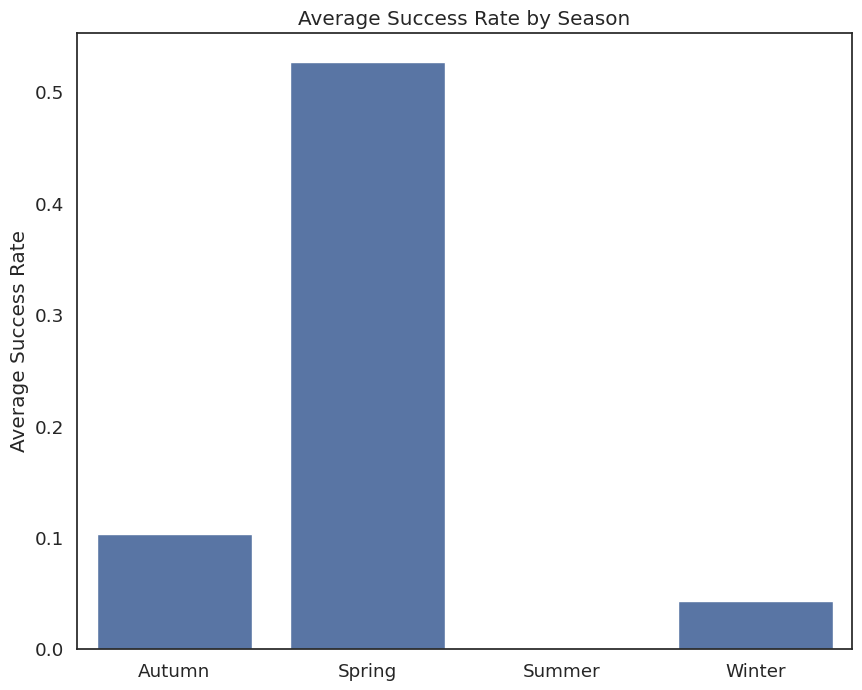

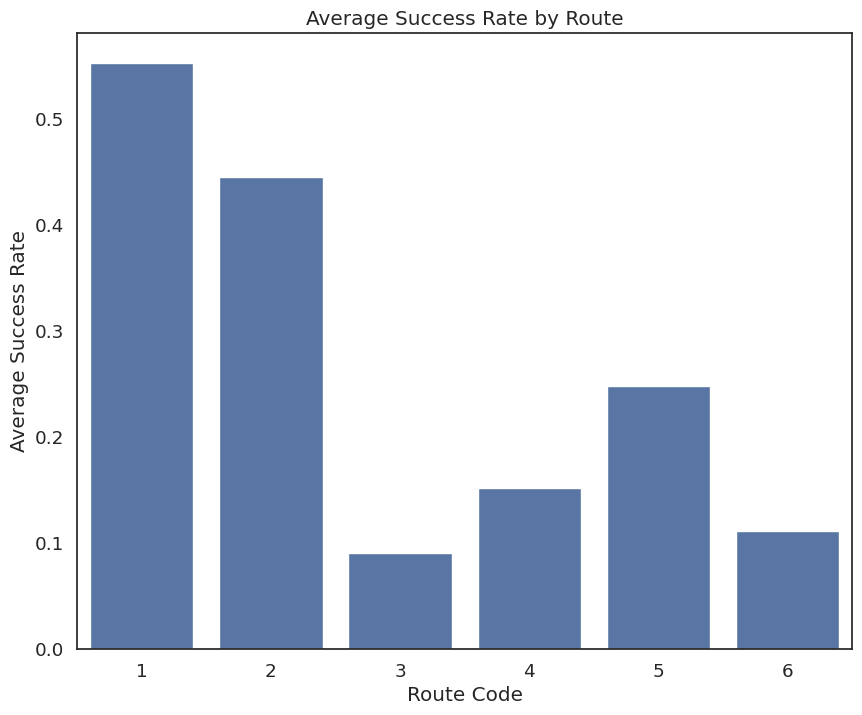

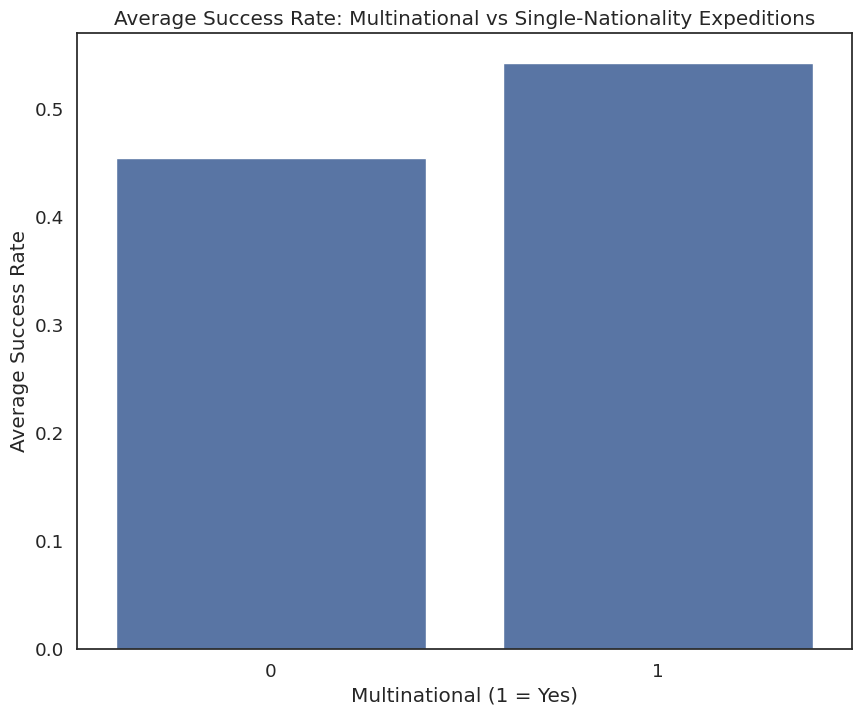

In [ ]:
#B: Mean success rate by category - bar charts

season_mean = (
    df_clean
    .groupby("Season")["success_rate"]
    .mean()
    .reset_index()
)

sns.barplot(data=season_mean, x="Season", y="success_rate")
plt.title("Average Success Rate by Season")
plt.xlabel("")
plt.ylabel("Average Success Rate")
plt.show()

route_mean = (
    df_clean.groupby("route_codes", as_index=False)["success_rate"]
    .mean()
)

sns.barplot(data=route_mean, x="route_codes", y="success_rate")
plt.title("Average Success Rate by Route")
plt.xlabel("Route Code")
plt.ylabel("Average Success Rate")
plt.show()


multi_mean = (
    df_clean.groupby("MultiNational", as_index=False)["success_rate"]
    .mean()
)

sns.barplot(data=multi_mean, x="MultiNational", y="success_rate")
plt.title("Average Success Rate: Multinational vs Single-Nationality Expeditions")
plt.xlabel("Multinational (1 = Yes)")
plt.ylabel("Average Success Rate")
plt.show()



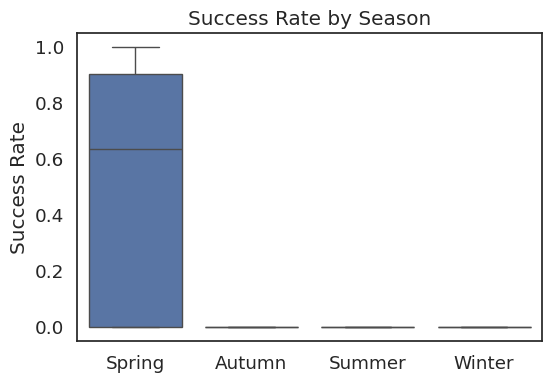

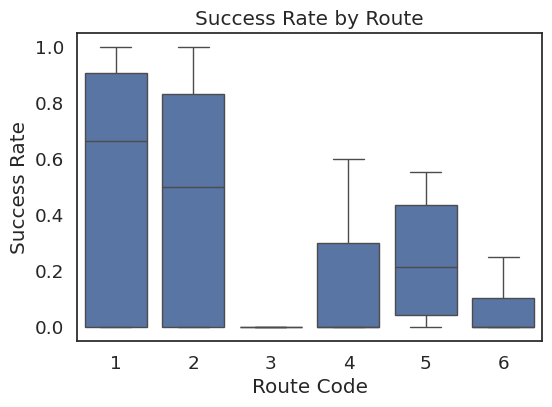

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_clean,
    x="Season",
    y="success_rate",
    showfliers=False,
    order=["Spring", "Autumn", "Summer", "Winter"]
)
plt.title("Success Rate by Season")
plt.xlabel("")
plt.ylabel("Success Rate")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_clean,
    x="route_codes",
    y="success_rate",
    showfliers=False
)
plt.title("Success Rate by Route")
plt.xlabel("Route Code")
plt.ylabel("Success Rate")
plt.show()

